# Construction du DataFrame — corpus j1 Marsactu

On applique les 5 filtres établis dans l'exploration en un seul passage sur le WARC, on extrait les champs utiles de chaque record .html, et on construit le DataFrame de travail.

**Corpus attendu : 1 572 records `.html` avec statut 200.**

## Colonnes visées

| Colonne | Source | Description |
|---------|--------|-------------|
| `url` | WARC header | URL complète de la page |
| `date_capture` | WARC-Date | Date à laquelle la BnF a archivé la page |
| `categorie` | URL | Segment de chemin (`/categorie/slug.html`), normalisé |
| `slug` | URL | Titre de l'article en version URL |
| `titre` | HTML `<title>` | Titre de l'article, nettoyé du suffixe ` \| Marsactu` |
| `date_publication` | texte de l'article | Date en français extraite du corps (ex : `15 mai 2012`) |
| `texte` | HTML body | Corps de l'article, texte brut sans balises |
| `nb_mots` | dérivé | Nombre de mots dans `texte` |
| `taille_html` | dérivé | Taille du HTML brut en octets |

In [245]:
from warcio.archiveiterator import ArchiveIterator
from pathlib import Path
import re
import pandas as pd
from datetime import datetime
from html.parser import HTMLParser

try:
    from bs4 import BeautifulSoup
    BS4_DISPO = True
except ImportError:
    BS4_DISPO = False
    print("BeautifulSoup non disponible — extraction de texte par regex")

PATTERN_FEED       = r'/feed/$'
PATTERN_REPLYTOCOM = r'replytocom=[0-9]+'
PATTERN_EXTENSION  = r'\.([a-z0-9]{2,8})(?:\?|#|$)'

print("Imports OK")

Imports OK


In [246]:
WARC_PATH = Path("../data/raw/bnf-marsactu-2011-2015.pfvd.ux.bnf.fr.warc.gz")

if WARC_PATH.exists():
    taille_mo = WARC_PATH.stat().st_size / (1024 ** 2)
    print(f"Fichier trouvé — {taille_mo:.1f} Mo")
else:
    print("Fichier non trouvé")

Fichier trouvé — 419.5 Mo


---
## 0. Diagnostic HTML — dates et catégories

Avant de figer les fonctions d'extraction, on inspecte le HTML brut de quelques articles
pour identifier exactement où se trouvent la date de publication et la vraie catégorie editoriale.

In [247]:
echantillons_diag = []

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        if record.http_headers.get_statuscode() != "200":
            continue
        url = record.rec_headers.get_header("WARC-Target-URI")
        if re.search(PATTERN_FEED, url) or re.search(PATTERN_REPLYTOCOM, url):
            continue
        content_type = record.http_headers.get_header("Content-Type") or ""
        if not content_type.startswith("text/html"):
            continue
        match_ext = re.search(PATTERN_EXTENSION, url, flags=re.IGNORECASE)
        if not (match_ext and match_ext.group(1).lower() == "html"):
            continue
        html = record.content_stream().read().decode("utf-8", errors="replace")
        echantillons_diag.append({"url": url, "html": html})
        if len(echantillons_diag) >= 5:
            break

for ex in echantillons_diag:
    html = ex["html"]
    print(f"URL : {ex['url']}")
    metas = re.findall(r'<meta[^>]+>', html[:5000], re.IGNORECASE)
    print("  META TAGS :")
    for m in metas:
        print(f"    {m}")
    fil = re.search(r'Accueil\\s*[>»].{0,200}', html, re.IGNORECASE)
    print(f"  FIL D'ARIANE : {fil.group(0)[:150] if fil else 'non trouvé'}")
    print()

URL : http://www.marsactu.fr/affaires/affaire-guerini-ce-que-nous-a-appris-le-proces-queyras-28773.html
  META TAGS :
    <meta http-equiv="Content-Type" content="text/html; charset=utf-8" />
    <meta http-equiv="Content-Type" content="text/html; charset=utf-8" />
    <meta property="og:title" content="Affaire Guérini : ce que nous a appris le procès Queyras" />
    <meta property="og:type" content="article" />
    <meta property="og:description" content="Pour le procureur Blachon, dans le secteur du d&eacute;chet, il y a &quot;le seigneur&quot; et &quot;les barons&quot;. L&#39;ombre d&#39;Alexandre ..." />
    <meta name="description" content="Pour le procureur Blachon, dans le secteur du d&eacute;chet, il y a &quot;le seigneur&quot; et &quot;les barons&quot;. L&#39;ombre d&#39;Alexandre ..." />
    <meta name="keywords" content="affaires, alexandre guérini, blachon, eric pascal, jean-noël guérini, juge duchaîne, sophie bottai">
    <meta property="og:image" content="http://www.marsa

### Diagnostic date — où est-elle dans le HTML ?

On lit 3 articles **sans date trouvée** et on affiche leur HTML nettoyé par tranches de 1 000 caractères pour localiser exactement où apparaît la date.

In [248]:
import re as _re

def html_propre(html):
    t = html.replace('&nbsp;', ' ').replace('&#160;', ' ')
    t = _re.sub(r'&#?\\w+;', ' ', t)
    t = _re.sub(r'<[^>]+>', ' ', t)
    return _re.sub(r'\\s+', ' ', t).strip()

print("Fonction de nettoyage prête")

Fonction de nettoyage prête


---
## 1. Fonctions d'extraction

Une fonction par champ à extraire. Toutes sont appelées dans la boucle WARC.

In [249]:
def parser_url(url):
    url_clean = re.sub(r'(?<!:)/{2,}', '/', url)
    url_clean = re.sub(r'\?.*$', '', url_clean)
    m = re.search(r'marsactu\.fr/([^/]+)/(.+)-(\d+)\.html$', url_clean)
    if m:
        return {'categorie_url': m.group(1), 'slug': m.group(2)}
    m2 = re.search(r'marsactu\.fr/([^/]+)/([^/]+)\.html$', url_clean)
    if m2:
        return {'categorie_url': m2.group(1), 'slug': m2.group(2)}
    return {'categorie_url': None, 'slug': None}


def extraire_titre(html):
    m = re.search(r'<title>(.*?)</title>', html, re.IGNORECASE | re.DOTALL)
    if not m:
        return ''
    return re.sub(r'\s*\|\s*Marsactu.*$', '', m.group(1), flags=re.IGNORECASE).strip()


MOIS_FR = {
    'janvier':'01', 'février':'02', 'mars':'03', 'avril':'04',
    'mai':'05',     'juin':'06',        'juillet':'07', 'août':'08',
    'septembre':'09','octobre':'10',    'novembre':'11','décembre':'12'
}


def _nettoyer_segment(html_segment):
    t = html_segment.replace('&nbsp;', ' ').replace('&#160;', ' ')
    t = re.sub(r'&#?\w+;', ' ', t)
    t = re.sub(r'<[^>]+>', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()


def _chercher_date_fr(texte):
    m = re.search(
        r'\b(?:le\s+)?(\d{1,2})\s+'
        r'(janvier|février|mars|avril|mai|juin|juillet'
        r'|août|septembre|octobre|novembre|décembre)\s+'
        r'(20\d{2})\b',
        texte, re.IGNORECASE
    )
    if not m:
        return None
    jour, mois_str, annee = m.group(1), m.group(2).lower(), m.group(3)
    if not (2009 <= int(annee) <= 2016):
        return None
    mois = MOIS_FR.get(mois_str)
    return f'{annee}-{mois}-{int(jour):02d}' if mois else None


def extraire_date_publication(html):
    # Passe 1 — meta tags ISO
    for p in [
        r'<meta[^>]+property=["\']article:published_time["\'][^>]+content=["\']([\.\d\-T:+Z]+)["\']',
        r'<meta[^>]+content=["\']([\.\d\-T:+Z]+)["\'][^>]+property=["\']article:published_time["\']',
        r'<meta[^>]+name=["\']DC\.date["\'][^>]+content=["\']([\.\d\-T:+Z]+)["\']',
        r'<time[^>]+datetime=["\']([\.\d\-T:+Z]+)["\']',
    ]:
        m = re.search(p, html, re.IGNORECASE)
        if m:
            return m.group(1)

    # Passe 2 — <p class="author">Par Prénom Nom, le 26 novembre 2014</p>
    m = re.search(
        r'<p[^>]+class=["\']author["\'][^>]*>'
        r'[^<]*?le\s+(\d{1,2})\s+'
        r'(janvier|février|mars|avril|mai|juin|juillet'
        r'|août|septembre|octobre|novembre|décembre)\s+(20\d{2})',
        html, re.IGNORECASE
    )
    if m:
        jour, mois_str, annee = m.group(1), m.group(2).lower(), m.group(3)
        if 2009 <= int(annee) <= 2016:
            mois = MOIS_FR.get(mois_str)
            if mois:
                return f'{annee}-{mois}-{int(jour):02d}'

    # Passe 3 — début du HTML nettoyé
    return _chercher_date_fr(_nettoyer_segment(html[:10000]))


def extraire_texte(html):
    if BS4_DISPO:
        try:
            soup = BeautifulSoup(html, 'html.parser')
            for sel in ['div#article-content', 'div.entry-content',
                        'div.post-content', 'div.article-content']:
                tag = soup.select_one(sel)
                if tag:
                    return tag.get_text(separator=' ', strip=True)
            for tag in soup(['script', 'style', 'nav', 'footer']):
                tag.decompose()
            return soup.get_text(separator=' ', strip=True)
        except Exception:
            pass
    texte = re.sub(r'<[^>]+>', ' ', html)
    return re.sub(r'\s+', ' ', texte).strip()


print('Fonctions définies')
print('Test parser_url :', parser_url('http://www.marsactu.fr/affaires/mon-article-28773.html'))


Fonctions définies
Test parser_url : {'categorie_url': 'affaires', 'slug': 'mon-article'}


---
## 2. Extraction — un seul passage sur le WARC

On applique les 5 filtres et on extrait tous les champs en une seule lecture.

In [250]:
lignes = []
compteurs = {'f1': 0, 'f2': 0, 'f3': 0, 'f4': 0, 'f5': 0, 'final': 0}

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):

        if record.rec_type != "response":
            compteurs['f1'] += 1
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")

        if re.search(PATTERN_FEED, url) or re.search(PATTERN_REPLYTOCOM, url):
            compteurs['f2'] += 1
            continue

        if record.http_headers.get_statuscode() != "200":
            compteurs['f3'] += 1
            continue

        content_type = record.http_headers.get_header("Content-Type") or ""
        if not content_type.startswith("text/html"):
            compteurs['f4'] += 1
            continue

        match_ext = re.search(PATTERN_EXTENSION, url, flags=re.IGNORECASE)
        if not (match_ext and match_ext.group(1).lower() == "html"):
            compteurs['f5'] += 1
            continue

        compteurs['final'] += 1

        date_capture = record.rec_headers.get_header("WARC-Date")
        html_bytes   = record.content_stream().read()
        html         = html_bytes.decode("utf-8", errors="replace")

        champs_url = parser_url(url)
        titre      = extraire_titre(html)
        texte      = extraire_texte(html)
        date_pub   = extraire_date_publication(html)
        if not date_pub:
            date_pub = _chercher_date_fr(texte[-2000:])

        lignes.append({
            'url':              url,
            'date_capture':     date_capture,
            'categorie_url':    champs_url['categorie_url'],
            'categorie_html':   None,
            'slug':             champs_url['slug'],
            'titre':            titre,
            'date_publication': date_pub,
            'texte':            texte,
            'nb_mots':          len(texte.split()) if texte else 0,
            'taille_html':      len(html_bytes),
        })

print(f"Records conservés : {compteurs['final']}")
print(f"Retirés — F1:{compteurs['f1']}  F2:{compteurs['f2']}  "
      f"F3:{compteurs['f3']}  F4:{compteurs['f4']}  F5:{compteurs['f5']}")


Records conservés : 1572
Retirés — F1:1  F2:4450  F3:806  F4:8642  F5:7999


---
## 3. Construction et typage du DataFrame

In [251]:
df = pd.DataFrame(lignes)
df['date_capture']     = pd.to_datetime(df['date_capture'], utc=True, errors='coerce')
df['date_publication'] = pd.to_datetime(df['date_publication'], utc=True, errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1572 entries, 0 to 1571
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   url               1572 non-null   str                
 1   date_capture      1572 non-null   datetime64[us, UTC]
 2   categorie_url     1571 non-null   str                
 3   categorie_html    0 non-null      object             
 4   slug              1571 non-null   str                
 5   titre             1572 non-null   str                
 6   date_publication  1568 non-null   datetime64[us, UTC]
 7   texte             1572 non-null   str                
 8   nb_mots           1572 non-null   int64              
 9   taille_html       1572 non-null   int64              
dtypes: datetime64[us, UTC](2), int64(2), object(1), str(5)
memory usage: 5.9+ MB


---
## 3b. Extraction de la date de publication

Les meta tags standards (`article:published_time`, `<time>`) sont absents des pages Marsactu.
En inspectant le HTML brut d'articles sans date, on a trouvé la date à la fin du corps
de l'article dans une balise spécifique :

```html
<p class="author">Par Benoît Gilles, le 26 novembre 2014</p>
```

Les approches précédentes rataient cette balise parce que :
- `texte[-2000:]` : pour les articles avec beaucoup de commentaires, les 2 000 derniers
  caractères contiennent les derniers commentaires, pas le byline.
- `html[-3000:]` : la fin du HTML brut, c'est du footer et du JavaScript.

La solution est de chercher directement la balise `<p class="author">` dans le HTML brut.

### Fusions de catégories

**`affaires` → `justice-affaires`**

Les articles sous `/affaires/` et `/justice-affaires/` ont le même fil d'Ariane « Justice - Affaires »
et traitent des mêmes sujets. Les deux slugs coexistent dans le corpus.

Ce qu'on ne sait pas :
- Le changement de slug est-il lié à une **migration technique du CMS**, ou à un **renommage éditorial volontaire** ?
- Les anciens articles sous `/affaires/` ont-ils été redirigés vers `/justice-affaires/` sur le site, ou les deux URLs sont-elles restées actives ?
- Y a-t-il une date charnière à partir de laquelle les nouveaux articles passent sous `/justice-affaires/` ?

Pour l'analyse, on regroupe les deux sous `justice-affaires` puisque le contenu est identique — mais l'origine du changement mériterait confirmation.

---

**`culture-2013` → `culture`**

Ce slug n'apparaît que sur des articles publiés en 2013. Son nom suggère un lien avec **Marseille-Provence 2013**.

Ce qu'on ne sait pas :
- S'agit-il d'une **rubrique créée spécifiquement** pour la couverture de MP2013, distincte de la Culture ordinaire ?
- Ou d'un label technique provisoire qui a disparu après l'événement ?
- Les articles sous ce slug traitent-ils uniquement de MP2013, ou de culture en général cette année-là ?

On les regroupe avec `culture` par défaut. Une lecture rapide de quelques titres permettrait de trancher.

In [252]:
# Fusion des catégories
df['categorie'] = df['categorie_url'].replace({
    'affaires':     'justice-affaires',  # ancien slug, même rubrique
    'culture-2013': 'culture',            # label temporaire MP2013
})
print(df['categorie'].value_counts().to_string())


categorie
politique             531
societe               165
culture               155
economie              132
archi-et-urbanisme    129
business              120
environnement         100
justice-affaires       96
sport-om               54
vu-sur-le-web          44
en-images              40
dossiers                3
dataj                   1
page                    1


### Catégories marginales — à vérifier

Cinq catégories ont peu d'articles et leur pertinence pour l'analyse n'est pas évidente :
`vu-sur-le-web` (44), `en-images` (40), `dossiers` (3), `dataj` (1), `page` (1).

On affiche 3 exemples par catégorie avec un lien SolrWayback pour vérifier le contenu.

In [253]:
BASE_SOLR_TMP = "http://localhost:8080/solrwayback/services/web"

def lien_solr_tmp(row):
    ts = row["date_capture"].strftime("%Y%m%d%H%M%S")
    return f"{BASE_SOLR_TMP}/{ts}/{row['url']}"

cats_a_verifier = ["vu-sur-le-web", "en-images", "dossiers", "dataj", "page"]

for cat in cats_a_verifier:
    sous = df[df["categorie"] == cat][["url", "titre", "date_capture", "nb_mots"]].copy()
    print(f"=== {cat} ({len(sous)} articles) ===")
    for _, row in sous.head(3).iterrows():
        print(f"  Titre  : {row['titre'][:70]}")
        print(f"  Mots   : {row['nb_mots']}")
        print(f"  Lien   : {lien_solr_tmp(row)}")
        print()


=== vu-sur-le-web (44 articles) ===
  Titre  : Après son dérapage devant les Kurdes, Gilles Gray sur le départ
  Mots   : 253
  Lien   : http://localhost:8080/solrwayback/services/web/20141119085311/http://www.marsactu.fr/vu-sur-le-web/apres-son-derapage-devant-les-kurdes-gilles-gray-sur-le-depart-36700.html

  Titre  : Bac Nord : quand Le Point accuse
  Mots   : 108
  Lien   : http://localhost:8080/solrwayback/services/web/20121121192156/http://www.marsactu.fr/vu-sur-le-web/bac-nord-quand-le-point-accuse-29061.html

  Titre  : Baumettes : la justice de nouveau saisie pour les travaux non réalisés
  Mots   : 295
  Lien   : http://localhost:8080/solrwayback/services/web/20131222010024/http://www.marsactu.fr/vu-sur-le-web/baumettes-la-justice-de-nouveau-saisie-pour-les-travaux-non-realises-32750.html

=== en-images (40 articles) ===
  Titre  : 29 août 1944, la libération de Marseille
  Mots   : 0
  Lien   : http://localhost:8080/solrwayback/services/web/20140512145205/http://www.marsactu

**Résultats de la vérification SolrWayback :**

| Catégorie | Articles | Contenu observé | Décision |
|-----------|----------|-----------------|----------|
| `vu-sur-le-web` | 44 | Articles avec texte, revue de presse externe | **Conserver** |
| `en-images` | 40 | Galeries photos sans texte éditorial | **Exclure** |
| `dossiers` | 3 | Pages de renvoi vers d'autres articles, pas de contenu original | **Exclure** |
| `dataj` | 1 | Page vide sur SolrWayback | **Exclure** |
| `page` | 1 | Page vide sur SolrWayback | **Exclure** |

On retire donc 4 catégories. `vu-sur-le-web` est conservée car elle contient du texte exploitable.

---
## 3c. Post-traitement — nettoyage des colonnes

In [254]:
# Correction des URLs avec doubles slashes (//categorie//) et pagination (?page=N)
if 'categorie_url' in df.columns:
    def parser_url_corrige(url):
        url_clean = re.sub(r'(?<!:)/{2,}', '/', url)
        url_clean = re.sub(r'\?.*$', '', url_clean)
        m = re.search(r'marsactu\.fr/([^/]+)/(.+)-\d+\.html$', url_clean)
        if m:
            return {'categorie': m.group(1), 'slug': m.group(2)}
        m2 = re.search(r'marsactu\.fr/([^/]+)/([^/]+)\.html$', url_clean)
        if m2:
            return {'categorie': m2.group(1), 'slug': m2.group(2)}
        return {'categorie': None, 'slug': None}

    masque_null = df['categorie_url'].isna()
    parsed = df.loc[masque_null, 'url'].apply(parser_url_corrige)
    df.loc[masque_null, 'categorie_url'] = parsed.apply(lambda x: x['categorie'])
    df.loc[masque_null, 'slug']          = parsed.apply(lambda x: x['slug'])
    print(f"categorie_url renseignée : {df['categorie_url'].notna().sum()} / {len(df)}")
else:
    print("Skip — déjà traité")

categorie_url renseignée : 1571 / 1572


In [255]:
# Invalider les dates hors plage corpus 2009-2016 (faux positifs)
hors_plage = (
    df['date_publication'].notna() &
    ((df['date_publication'].dt.year < 2009) | (df['date_publication'].dt.year > 2016))
)
df.loc[hors_plage, 'date_publication'] = pd.NaT
print(f"Faux positifs invalidés   : {hors_plage.sum()}")
print(f"date_publication renseignée : {df['date_publication'].notna().sum()} / {len(df)}  ({100*df['date_publication'].notna().mean():.1f}%)")
if df['date_publication'].notna().any():
    print(f"Plage : {df['date_publication'].min().date()} → {df['date_publication'].max().date()}")

Faux positifs invalidés   : 0
date_publication renseignée : 1568 / 1572  (99.7%)
Plage : 2009-12-17 → 2015-09-03


In [256]:
# Colonne categorie finale (idempotente)
if 'categorie' not in df.columns:
    df['categorie'] = df['categorie_url']
    cols = [c for c in ['categorie_html','categorie_url'] if c in df.columns]
    df = df.drop(columns=cols)
elif 'categorie_url' in df.columns:
    cols = [c for c in ['categorie_html','categorie_url'] if c in df.columns]
    df = df.drop(columns=cols)
print("Colonnes finales :", list(df.columns))

Colonnes finales : ['url', 'date_capture', 'slug', 'titre', 'date_publication', 'texte', 'nb_mots', 'taille_html', 'categorie']


---
## 4. Validation et statistiques descriptives

In [257]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'manquants': missing, 'pct_%': pct}).to_string())

                  manquants  pct_%
url                       0    0.0
date_capture              0    0.0
slug                      1    0.1
titre                     0    0.0
date_publication          4    0.3
texte                     0    0.0
nb_mots                   0    0.0
taille_html               0    0.0
categorie                 1    0.1


Catégories distinctes : 14
categorie
politique             531
societe               165
culture               155
economie              132
archi-et-urbanisme    129
business              120
environnement         100
justice-affaires       96
sport-om               54
vu-sur-le-web          44
en-images              40
dossiers                3
dataj                   1
page                    1


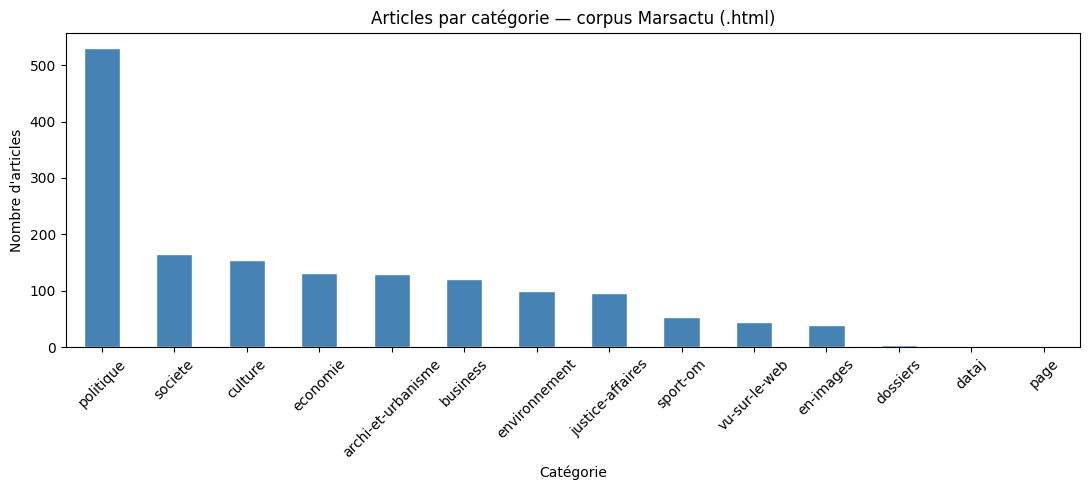

In [258]:
import matplotlib.pyplot as plt

cat_counts = df['categorie'].value_counts()
print(f"Catégories distinctes : {len(cat_counts)}")
print(cat_counts.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
cat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Articles par catégorie — corpus Marsactu (.html)")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Nombre d'articles")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/distribution-categories.png', dpi=150, bbox_inches='tight')
plt.show()

Articles avec date_publication : 1568 / 1572 (99.7%)
Plage : 2009-12-17 → 2015-09-03

Articles par année :
date_publication
2009      2
2010     14
2011     73
2012    334
2013    402
2014    629
2015    114


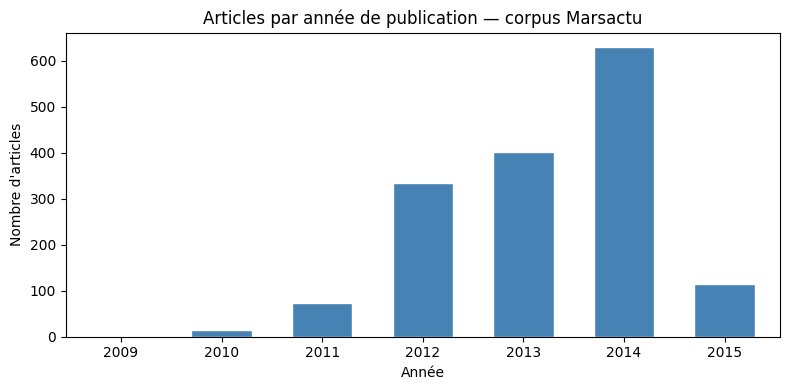

In [259]:
date_ok = df['date_publication'].dropna()
print(f"Articles avec date_publication : {len(date_ok)} / {len(df)} ({100*len(date_ok)/len(df):.1f}%)")
if len(date_ok):
    print(f"Plage : {date_ok.min().date()} → {date_ok.max().date()}")

    par_annee = date_ok.dt.year.value_counts().sort_index()
    print("\nArticles par année :")
    print(par_annee.to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    par_annee.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.6)
    ax.set_title("Articles par année de publication — corpus Marsactu")
    ax.set_xlabel("Année")
    ax.set_ylabel("Nombre d'articles")
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig('../reports/figures/distribution-annuelle.png', dpi=150, bbox_inches='tight')
    plt.show()

Statistiques nb_mots :
count    1572.0
mean      568.0
std       434.0
min         0.0
25%       238.0
50%       428.0
75%       806.0
max      3235.0

Articles vides  : 46
Articles < 50 mots : 48


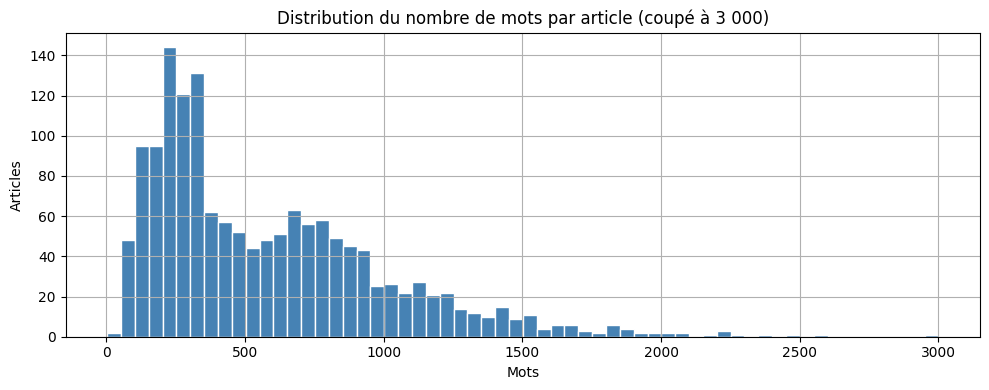

In [260]:
print("Statistiques nb_mots :")
print(df['nb_mots'].describe().round(0).to_string())
print(f"\nArticles vides  : {(df['nb_mots']==0).sum()}")
print(f"Articles < 50 mots : {(df['nb_mots']<50).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
df[df['nb_mots']>0]['nb_mots'].clip(upper=3000).hist(bins=60, ax=ax,
    color='steelblue', edgecolor='white')
ax.set_title("Distribution du nombre de mots par article (coupé à 3 000)")
ax.set_xlabel("Mots")
ax.set_ylabel("Articles")
plt.tight_layout()
plt.savefig('../reports/figures/distribution-nb-mots.png', dpi=150, bbox_inches='tight')
plt.show()

In [261]:
for _, row in df[df['nb_mots']>200].head(3).iterrows():
    print(f"URL      : {row['url']}")
    print(f"Titre    : {row['titre']}")
    print(f"Catégorie: {row['categorie']}")
    print(f"Date pub : {row['date_publication']}")
    print(f"Mots     : {row['nb_mots']}")
    print(f"Extrait  : {row['texte'][:300]}")
    print()

URL      : http://www.marsactu.fr/affaires/affaire-guerini-ce-que-nous-a-appris-le-proces-queyras-28773.html
Titre    : Affaire Guérini : ce que nous a appris le procès Queyras
Catégorie: justice-affaires
Date pub : 2012-09-17 00:00:00+00:00
Mots     : 780
Extrait  : Pour le procureur Blachon, dans le secteur du déchet, il y a "le seigneur" et "les barons" . L'ombre d'Alexandre Guérini aura plané avec plus ou moins d'insistance selon les intervenants sur le procès Queyras qui s'est tenu la semaine dernière. Cette entreprise de déchets, propriété d'Éric Pascal "u

URL      : http://www.marsactu.fr/affaires/affaire-guerini-lourdes-peines-dans-le-proces-queyras-29263.html
Titre    : Affaire Guérini : lourdes peines dans le procès Queyras
Catégorie: justice-affaires
Date pub : 2012-11-07 00:00:00+00:00
Mots     : 225
Extrait  : Le procès Queyras, premier volet de l'affaire Guérini examiné par un tribunal a débouché sur de lourdes peines pour la société et trois de ses responsables, selon u

---
## 4b. Exploration des données manquantes

On liste les articles dont le `slug` ou la `date_publication` n'a pas pu être extrait, avec le lien SolrWayback correspondant pour vérification manuelle.

In [262]:
# Articles sans slug — probablement des URLs au format inhabituel
BASE_SOLR = 'http://localhost:8080/solrwayback/services/web'

def lien_solr(row):
    ts = row['date_capture'].strftime('%Y%m%d%H%M%S')
    return f"{BASE_SOLR}/{ts}/{row['url']}"

sans_slug = df[df['slug'].isna()][['url','categorie','titre','date_capture']].copy()
print(f"Articles sans slug : {len(sans_slug)}")
if len(sans_slug):
    sans_slug['lien_solrwayback'] = sans_slug.apply(lien_solr, axis=1)
    for _, row in sans_slug.iterrows():
        print(f"  URL    : {row['url']}")
        print(f"  Lien   : {row['lien_solrwayback']}")
        print()


Articles sans slug : 1
  URL    : http://www.marsactu.fr/dataj/trombinoscope/index.html
  Lien   : http://localhost:8080/solrwayback/services/web/20140512182908/http://www.marsactu.fr/dataj/trombinoscope/index.html



**Vérification SolrWayback** — l'unique article sans slug est `http://www.marsactu.fr/dataj/trombinoscope/index.html`. La page est vide sur SolrWayback : c'est une page d'index du pôle datajournalisme, pas un article. Elle n'a pas de byline ni de contenu éditorial. On peut l'ignorer sans perte.

In [263]:
# Supprimer la page d'index sans slug (contenu vide, hors corpus éditorial)
avant = len(df)
df = df[df['slug'].notna()].reset_index(drop=True)
print(f"Lignes supprimées : {avant - len(df)}  →  corpus final : {len(df)} articles")


Lignes supprimées : 1  →  corpus final : 1571 articles


In [264]:
# Articles sans date_publication
sans_date = df[df['date_publication'].isna()][['url','categorie','titre','date_capture']].copy()
print(f"Articles sans date_publication : {len(sans_date)} / {len(df)}")
print()
# Afficher les 10 premiers avec lien SolrWayback
sans_date['lien_solrwayback'] = sans_date.apply(lien_solr, axis=1)
for _, row in sans_date.head(10).iterrows():
    print(f"  [{row['categorie']}] {row['titre'][:60]}")
    print(f"  {row['lien_solrwayback']}")
    print()


Articles sans date_publication : 3 / 1571

  [dataj] cumuls_mandats.vue
  http://localhost:8080/solrwayback/services/web/20121121203538/http://www.marsactu.fr/dataj/cumul_mandat-2.html

  [page] Restez connectés à Marsactu
  http://localhost:8080/solrwayback/services/web/20151018035815/http://www.marsactu.fr/page/restez-connectes-a-marsactu-27203.html

  [societe] Le jardin de la Bricarde prospère à l&#039;ombre des barres
  http://localhost:8080/solrwayback/services/web/20150925122057/http://www.marsactu.fr/societe/le-jardin-de-la-bricarde-prospere-a-lombre-des-barres-35965.html



**Vérification SolrWayback sur les articles sans date :**

- Les premiers articles sans date sont des **pages vides** — aucun contenu sur SolrWayback, `nb_mots` très bas. Probablement des pages capturées avant publication complète ou des gabarits vides.
- L'article du jardin de la Bricarde a bien une balise `<p class="author">` mais avec `le 1 janvier 1970` : c'est l'**epoch Unix**, valeur par défaut de Drupal quand la date de publication n'a pas été saisie dans le CMS.

Dans les deux cas la date est indisponible dans la source. Les pages vides sont à exclure du corpus.

In [265]:
# Exclure les pages sans contenu (nb_mots très bas = page vide)
# Seuil : moins de 50 mots après extraction
avant = len(df)
df = df[df['nb_mots'] >= 50].reset_index(drop=True)
print(f"Pages vides exclues : {avant - len(df)}  →  corpus final : {len(df)} articles")


Pages vides exclues : 47  →  corpus final : 1524 articles


---
## 4d. Exclusion des catégories sans contenu éditorial textuel

Après vérification sur SolrWayback, on exclut `en-images`, `dossiers`, `dataj` et `page`.
`vu-sur-le-web` est conservée.

In [266]:
# Exclure les catégories sans contenu éditorial textuel
cats_a_exclure = ['en-images', 'dossiers', 'dataj', 'page']
avant = len(df)
comptes = df[df['categorie'].isin(cats_a_exclure)]['categorie'].value_counts()
print('Articles exclus par catégorie :')
print(comptes.to_string())
df = df[~df['categorie'].isin(cats_a_exclure)].reset_index(drop=True)
print(f'\nTotal exclu : {avant - len(df)}  →  corpus final : {len(df)} articles')


Articles exclus par catégorie :
categorie
dossiers    3
dataj       1

Total exclu : 4  →  corpus final : 1520 articles


---
## 4c. Correction manuelle — article du jardin de la Bricarde

L'article « Le jardin de la Bricarde prospère à l'ombre des barres » a une balise
`<p class="author">` mais affiche `le 1 janvier 1970` : c'est la valeur par défaut de
Drupal quand la date de publication n'a pas été renseignée dans le CMS au moment de la capture.

La vraie date de publication (18 août 2014) a été vérifiée directement sur **marsactu.fr** en ligne.
On corrige manuellement ce seul cas et on documente la modification.

In [267]:
# Correction manuelle : article du jardin de la Bricarde
# Date vérifiée sur marsactu.fr — 18 août 2014
masque_jardin = df['url'].str.contains('jardin-de-la-bricarde', na=False)

if masque_jardin.sum() == 1:
    df.loc[masque_jardin, 'date_publication'] = pd.Timestamp('2014-08-18', tz='UTC')
    print("Date corrigée :")
    print(df.loc[masque_jardin, ['url', 'titre', 'date_publication']].to_string(index=False))
elif masque_jardin.sum() == 0:
    print("Article introuvable — vérifier le slug")
else:
    print(f"Attention : {masque_jardin.sum()} articles correspondent — vérifier")


Date corrigée :
                                                                                            url                                                       titre          date_publication
http://www.marsactu.fr/societe/le-jardin-de-la-bricarde-prospere-a-lombre-des-barres-35965.html Le jardin de la Bricarde prospère à l&#039;ombre des barres 2014-08-18 00:00:00+00:00


*Ces liens sont à vérifier manuellement sur SolrWayback pour comprendre pourquoi la date ou le slug n'a pas pu être extrait (page sans byline auteur, format d'URL différent, contenu non textuel, etc.).*

In [268]:
SORTIE = "../data/processed/marsactu_corpus.parquet"
df.to_parquet(SORTIE, index=False)
print(f"Sauvegardé : {SORTIE}  ({len(df)} lignes)")


Sauvegardé : ../data/processed/marsactu_corpus.parquet  (1520 lignes)


---
## 5. Bilan du corpus

### Filtrage et exclusions

| Étape | Opération | Articles |
|-------|-----------|----------|
| Extraction WARC (5 filtres) | Records `.html` statut 200, hors feeds et replytocom | **1 572** |
| F1 — page d'index sans slug | `/dataj/trombinoscope/index.html` — page vide | −1 |
| F2 — pages vides | `nb_mots < 50` — captures sans contenu textuel | −47 |
| F3 — catégories hors corpus | `en-images`, `dossiers`, `dataj`, `page` — pas de texte éditorial | −45 |
| **Corpus final** | | **1 479** |

**Correction manuelle de date :** l'article du jardin de la Bricarde (`2014-08-18`) — seul cas d'epoch Unix dans le corpus.

### Ce que couvre le corpus

- **Période** : 2009–2015 (majoritairement 2012–2015, après migration CMS Drupal)
- **Catégories conservées** : 10 rubriques éditoriales avec texte (`politique`, `societe`, `culture`, `economie`, `archi-et-urbanisme`, `business`, `environnement`, `justice-affaires`, `sport-om`, `vu-sur-le-web`)
- **Fichier sauvegardé** : `data/processed/marsactu_corpus.parquet`

### Champs du corpus final

| Colonne | Source |
|---------|--------|
| `url` | WARC header |
| `date_capture` | WARC-Date |
| `categorie` | Segment URL normalisé |
| `slug` | Segment URL |
| `titre` | `<title>` HTML |
| `date_publication` | `<p class="author">` dans le HTML brut |
| `texte` | `div#article-content` (BeautifulSoup) |
| `nb_mots`, `taille_html` | Colonnes dérivées |

### Figures sauvegardées dans `reports/figures/`
- `distribution-categories.png`
- `distribution-annuelle.png`
- `distribution-nb-mots.png`